In [1]:
from xbbg import blp
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from datetime import datetime, timedelta

from scipy.stats import percentileofscore

from itertools import product

In [2]:
# 1. Gauge Market Sentiment -- Net Long Vs Net Short

# 2. Contrarian Signal (Spot Extreme Pos) -- Extreme Long or Short --  potencially signaling over bought/sold

# 3. Monitor Crowded Trades -- High Speculative positions = overcrowded -- Vulnerable to surprise events

# 4. Potencial Divergance -- If 

# 5. Potencial Breakouts -- Quick transitions from neutral to long/short  -- Strong Following Trend

# 6. Risk Sentiment -- Safe Haven (JPY,CHF) vs Risk On (AUD,CAD) Market -- Gauge market risk sentiment 

# 7. Timing Rebalance or Hedging -- If speculations are extreme - favoriabe time to hedge position


In [3]:
# --------------------------------------------------------------------------------------------------------------------------
# ----------------------------------- Institutions Vs Speculators ----------------------------------------------------------
# --------------------------------------------------------------------------------------------------------------------------

# Data Frame of all Institutional Vs Speculators CFTC Data
def Inst_Spec_futurePositioning(spot, years):


    # ----- Getting futures codes based on ccy ticker -----
    if spot == 'EURUSD': # Euro Dollar
        ccy_F = "IMMBE"
        ccy_F_O = 'IMMPF'

    if spot == 'USDJPY': # Dollar Yen
        ccy_F = "IMM5J"
        ccy_F_O = "IMMOJ"

    if spot == 'GBPUSD': # Pound Dollar
        ccy_F = "IMM5P"
        ccy_F_O = "IMMOP"

    if spot == 'USDCAD': # Dollar Cad
        ccy_F = "IMM3C"
        ccy_F_O = "IMMOC"

    if spot == 'AUDUSD': # Aussie Dollar
        ccy_F = "IMM6A"
        ccy_F_O = "IMMOA"

    if spot == 'NZDUSD': # Kiwi Dollar
        ccy_F = "IMM6Z"
        ccy_F_O = "IMMTZ"

    if spot == 'USDCHF': # Dollar Swiss
        ccy_F = "IMM4S"
        ccy_F_O = "IMMTS"

    if spot == 'EURGBP': # Euro Pound
        ccy_F = "CFF8E"
        ccy_F_O = "CFC8T"





    spot_tick = f"{spot} Curncy"


    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=years * 365)).strftime("%Y-%m-%d")

    # Catagory Codes 
    codes = [
        'TLL', 'TLS', 'TLN',  # Total Positions   (Long, Short, Net)
        'NCL', 'NCS', 'NCP', 'NCN',  # Speculators Positions   (Long, Short, Spreading, Net)
        'COL', 'COS', 'CON'  # Institutional Hedgers   (Long, Short, Net)
    ]


    column_names = [
        'tot_Long', 'tot_Short', 'tot_Net',
        'spec_Long', 'spec_Short', 'spec_Spreading', 'spec_Net',
        'inst_Long', 'inst_Short', 'inst_Net'
    ]


    ticker = [f"{base}{code}" for base in [ccy_F, ccy_F_O] for code in codes] # Generating combo of all tickers (All Futures THEN All Fut&Opt)
    ticker = [f"{code} Index" for code in ticker] # 


    # Pull data using blp.bdh()
    df_data = blp.bdh(
        tickers=ticker,
        start_date=start_date,
        end_date=end_date
    )

    df_data.columns = ['_'.join(col).strip() for col in df_data.columns.values] # Join column headers into 1


    # Re-structuring of column names in CME Data 
    tickers = [f"{base}{code} Index_Last_Price" for base in [ccy_F, ccy_F_O] for code in codes]
    columns_with_names = {
        ticker: f"{f'{spot}_F' if ccy_F in ticker else f'{spot}_F_O'}_{column_names[i % len(column_names)]}"
        for i, ticker in enumerate(tickers)}
    df_data.rename(columns=columns_with_names, inplace=True)

    # Gathering Spot Data
    df_spot = blp.bdh(
        tickers=spot_tick,
        start_date=start_date,
        end_date=end_date
    )

    # Re-structuring of column names in spot data
    df_spot.columns = ['_'.join(col).strip() for col in df_spot.columns.values]
    df_spot.rename(columns={f"{spot} Curncy_Last_Price": spot_tick}, inplace=True)

    # Merging Fut&Opt data with Spot data
    df_data[f'{spot_tick}'] = df_spot[f'{spot_tick}']
    df_data.insert(0, f'{spot_tick}', df_data.pop(f'{spot_tick}'))


    return df_data, df_spot








# Plot Total Ratio Long/Short and Spot over time 
def plotTotalLongShort_spot(spot, years): 

    df_data, df_spot = Inst_Spec_futurePositioning(spot, years)

    df_data['F_tot_longVshort'] = df_data[f'{spot}_F_tot_Long'] / df_data[f'{spot}_F_tot_Short']


    # Create the figure and axes
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot spot on the left y-axis
    ax1.plot(df_spot.index, df_spot[f"{spot} Curncy"], color='blue', label= f"{spot} Curncy")
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f"{spot} Curncy", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    # Create a twin y-axis for F_tot_longVshort
    ax2 = ax1.twinx()
    ax2.plot(df_data.index, df_data['F_tot_longVshort'], color='red', label='Long/Short')
    ax2.set_ylabel('long Vs short Ratio', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    # Add a title and legend
    plt.title(f'{spot} Spot and Long/Short Ratio Over Time')
    fig.tight_layout()
    plt.grid(True)

    # Show the plot
    plt.show()

    return




# Plot Spectulators Ratio Long/Short and Spot over time 
def plotSpecLongShort_spot(spot, years): 

    df_data, df_spot = Inst_Spec_futurePositioning(spot, years)

    df_data['F_spec_longVshort'] = df_data[f'{spot}_F_spec_Long'] / df_data[f'{spot}_F_spec_Short']


    # Create the figure and axes
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot spot on the left y-axis
    ax1.plot(df_spot.index, df_spot[f"{spot} Curncy"], color='blue', label= f"{spot} Curncy")
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f"{spot} Curncy", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    # Create a twin y-axis for F_tot_longVshort
    ax2 = ax1.twinx()
    ax2.plot(df_data.index, df_data['F_spec_longVshort'], color='red', label='Long/Short')
    ax2.set_ylabel('Speculators long Vs short Ratio', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    # Add a title and legend
    plt.title(f'{spot} Spot and Speculators Long/Short Ratio Over Time')
    fig.tight_layout()
    plt.grid(True)

    # Show the plot
    plt.show()

    return



# Plot Institutional Ratio Long/Short and Spot over time 
def plotInstLongShort_spot(spot, years): 

    df_data, df_spot = Inst_Spec_futurePositioning(spot, years)

    df_data['F_inst_longVshort'] = df_data[f'{spot}_F_inst_Long'] / df_data[f'{spot}_F_inst_Short']


    # Create the figure and axes
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot spot on the left y-axis
    ax1.plot(df_spot.index, df_spot[f"{spot} Curncy"], color='blue', label= f"{spot} Curncy")
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f"{spot} Curncy", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    # Create a twin y-axis for F_tot_longVshort
    ax2 = ax1.twinx()
    ax2.plot(df_data.index, df_data['F_inst_longVshort'], color='red', label='Long/Short')
    ax2.set_ylabel('Institutional long Vs short Ratio', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')

    # Add a title and legend
    plt.title(f'{spot} Spot and Institutional Long/Short Ratio Over Time')
    fig.tight_layout()
    plt.grid(True)

    # Show the plot
    plt.show()

    return


# Plot a (A List of) variables of choice
def plotVariableChoice_spot(spot, years, varChoices):

    df_data, df_spot = Inst_Spec_futurePositioning(spot, years)

    # Create the figure and axes
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Plot spot on the left y-axis
    ax1.plot(df_spot.index, df_spot[f"{spot} Curncy"], color='blue', label=f"{spot} Curncy")
    ax1.set_xlabel('Date')
    ax1.set_ylabel(f"{spot} Curncy", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    # Create a twin y-axis for the varChoices
    ax2 = ax1.twinx()

    # Loop through varChoices and plot each on the same secondary y-axis
    colors = ['red', 'green', 'orange', 'purple', 'brown']  # Add more colors if needed
    for i, varChoice in enumerate(varChoices):
        ax2.plot(df_data.index, df_data[varChoice], label=varChoice, color=colors[i % len(colors)])

    ax2.set_ylabel('Values', color='black')  # General label for the secondary y-axis
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.legend(loc='upper right')

    # Add a title and legend
    plt.title(f'{spot} Spot and {", ".join(varChoices)} Over Time')
    fig.tight_layout()
    plt.grid(True)

    # Show the plot
    plt.show()

    return








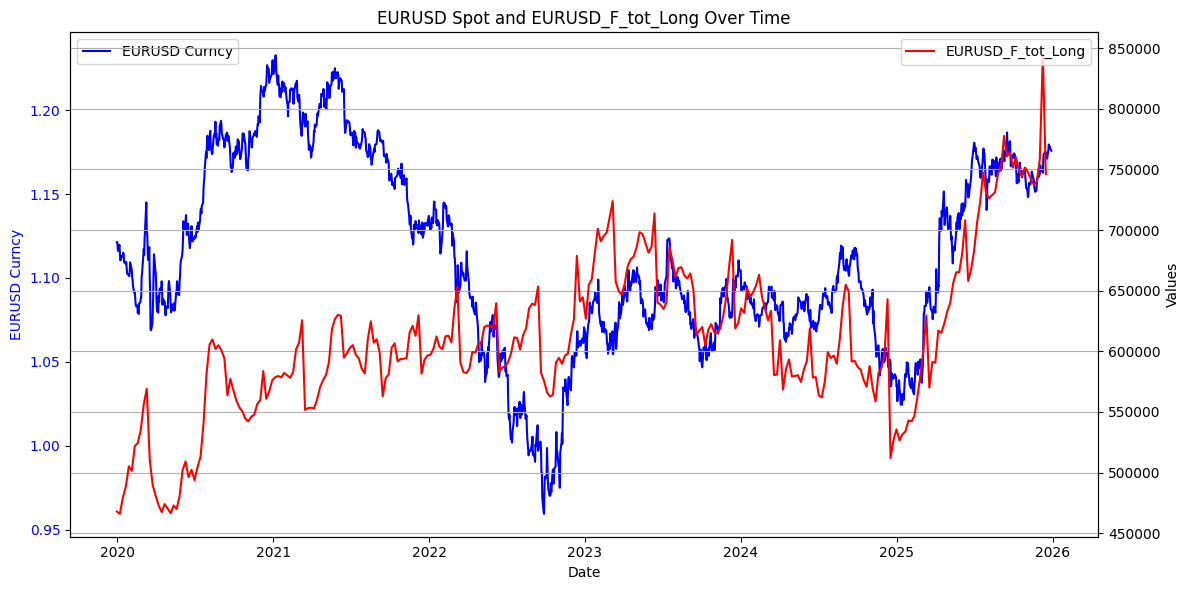

In [4]:
spot = 'EURUSD'

varChoices = ['EURUSD_F_tot_Long']
years = 6


plotVariableChoice_spot(spot, years, varChoices)

In [5]:
# 2. Contrarian Signal (Spot Extreme Pos) -- Extreme Long or Short --  potencially signaling over bought/sold

spot = "EURUSD"


df_data, df_spot = Inst_Spec_futurePositioning(spot)

df_data.columns

TypeError: Inst_Spec_futurePositioning() missing 1 required positional argument: 'years'

In [6]:
most_recent_row = df_data.iloc[-1]

percentiles = {
    col: percentileofscore(df_data[col].dropna(), most_recent_row[col]) for col in df_data.columns
}

NameError: name 'df_data' is not defined

In [7]:
percentiles

NameError: name 'percentiles' is not defined

In [5]:
# --------------------------------------------------------------------------------------------------------------------------
# ----------------------------------- Traders of Futures ----------------------------------------------------------
# --------------------------------------------------------------------------------------------------------------------------

# Data Frame of Traders in Financial Futures from CFTC Data
def Traders_futurePositioning(spot, years):


    # ----- Getting futures codes based on ccy ticker -----
    if spot == 'EURUSD': # Euro Dollar
        ccy_F = "TFF1E"
        ccy_F_O = 'TFC1E'

    if spot == 'USDJPY': # Dollar Yen
        ccy_F = "TFF1D"
        ccy_F_O = "TFC1D"

    if spot == 'GBPUSD': # Pound Dollar
        ccy_F = "TFF1C"
        ccy_F_O = "TFC1C"

    if spot == 'USDCAD': # Dollar Cad
        ccy_F = "TFF1A"
        ccy_F_O = "TFC1A"

    if spot == 'AUDUSD': # Aussie Dollar
        ccy_F = "TFF1F"
        ccy_F_O = "TFC1F"

    if spot == 'NZDUSD': # Kiwi Dollar
        ccy_F = "TFF1I"
        ccy_F_O = "TFC1I"

    if spot == 'USDCHF': # Dollar Swiss
        ccy_F = "TFF1B"
        ccy_F_O = "TFC1B"

    if spot == 'USD':
        ccy_F = 'TFF2N'
        ccy_F_O = 'TFC2N'

    if spot == 'EURGBP': # Euro Pound
        ccy_F = "TFF3E"
        ccy_F_O = "TFC3E"





    spot_tick = f"{spot} Curncy"


    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=years * 365)).strftime("%Y-%m-%d")



    # List of corresponding codes 
    #   (LONG, SHORT, SPREAD, NET)
    codes = [
        "AIL", "AIS", "AID", "AIN", 
        "DIL", "DIS", "DID", "DIN", 
        "LFL", "LFS", "LFD", "LFN", 
        "ORL", "ORS", "ORD", "ORN"
    ]




    # Catagory Codes 
    column_names = [
        "AM_Long", "AM_Short", "AM_Spreading", "AM_Net",        # Assent Managers 
        "Dealer_Long", "Dealer_Short", "Dealer_Spreading", "Dealer_Net",        # Dealer Intermediary
        "Lever_Long", "Lever_Short", "Lever_Spreading", "Lever_Net",        # Leveraged Funds
        "Other_Long", "Other_Short", "Other_Spreading", "Other_Net"     # Other reportables
    ]

    

    ticker = [f"{base}{code}" for base in [ccy_F, ccy_F_O] for code in codes] # Generating combo of all tickers (All Futures THEN All Fut&Opt)
    ticker = [f"{code} Index" for code in ticker] # 


    # Pull data using blp.bdh()
    df_data = blp.bdh(
        tickers=ticker,
        start_date=start_date,
        end_date=end_date
    )

    df_data.columns = ['_'.join(col).strip() for col in df_data.columns.values] # Join column headers into 1


    # Re-structuring of column names in CME Data 
    tickers = [f"{base}{code} Index_Last_Price" for base in [ccy_F, ccy_F_O] for code in codes]
    columns_with_names = {
        ticker: f"{f'{spot}_F' if ccy_F in ticker else f'{spot}_F_O'}_{column_names[i % len(column_names)]}"
        for i, ticker in enumerate(tickers)}
    df_data.rename(columns=columns_with_names, inplace=True)

    # Gathering Spot Data
    df_spot = blp.bdh(
        tickers=spot_tick,
        start_date=start_date,
        end_date=end_date
    )

    # Re-structuring of column names in spot data
    df_spot.columns = ['_'.join(col).strip() for col in df_spot.columns.values]
    df_spot.rename(columns={f"{spot} Curncy_Last_Price": spot_tick}, inplace=True)

    # Merging Fut&Opt data with Spot data
    df_data[f'{spot_tick}'] = df_spot[f'{spot_tick}']
    df_data.insert(0, f'{spot_tick}', df_data.pop(f'{spot_tick}'))


    return df_data, df_spot

In [6]:
# All CCY futures ppositioning data pull
def Traders_Agg_futurePositioning(years):
    end_date = datetime.now().strftime("%Y-%m-%d")
    start_date = (datetime.now() - timedelta(days=years * 365)).strftime("%Y-%m-%d")

    ccy_codes = [
        "TFF1E",  # EURUSD
        "TFF1D",  # JPYUSD
        "TFF1C",  # GBPUSD
        "TFF1A",  # CADUSD
        "TFF1F",  # AUDUSD
        "TFF1I",  # NZDUSD
        "TFF1B",  # USDCHF
        "TFF2V",  # BLRUSD
        "TFF1H"  # MXNUSD
    ]


    # List of corresponding codes 
    #   (LONG, SHORT)
    codes = [
        "AIL", "AIS",  # Asset Manager positioning 
        "LFL", "LFS",  # Leveraged Funds Positioning
        ]



    ccy_tickers = [
        'EURUSD',
        'JPYUSD',
        'GBPUSD',
        'CADUSD',
        'AUDUSD',
        'NZDUSD',
        'CHFUSD',
        'BRLUSD',
        'MXNUSD'
    ]


    # Catagory Codes 
    column_names = [
        "AM_Long", "AM_Short",         # Assent Managers 
        "Lever_Long", "Lever_Short",      # Leveraged Funds
    ]


    combined_codes = [f"{ticker}{code}" for ticker, code in product(ccy_codes, codes)]
    ticker = [f"{code} Index" for code in combined_codes]



    df_data = blp.bdh(
            tickers=ticker,
            start_date=start_date,
            end_date=end_date
        )

    df_data.columns = ['_'.join(col).strip() for col in df_data.columns.values] # Join column headers into 1

    # Renaming columns for clarity
    new_column_names = [f"{ccy}_{col}" for ccy in ccy_tickers for col in column_names] 
    df_data.columns = new_column_names

    return df_data





# Plotting BarChart of all positioning data (Past two report comparison) for Leveraged funds and Asset Managers
def plotTraderPositionalBarChart(years):



    ccy_tickers = [
        'EURUSD',
        'JPYUSD',
        'GBPUSD',
        'CADUSD',
        'AUDUSD',
        'NZDUSD',
        'CHFUSD',
        'BRLUSD',
        'MXNUSD'
    ]

    df_data = Traders_Agg_futurePositioning(years)
    



    AM_LongShort = {}
    Lever_LongSHort = {}

    # Loop through each currency in ccy_tickers
    for ccy in ccy_tickers:
        # Calculate the ratio of AM_Long to AM_Short
        AM_LongShort[f"{ccy}_AM_LongShort"] = df_data[f"{ccy}_AM_Long"] / df_data[f"{ccy}_AM_Short"]
        Lever_LongSHort[f"{ccy}_AM_LongShort"] = df_data[f"{ccy}_Lever_Long"] / df_data[f"{ccy}_Lever_Short"]

    # Convert the dictionary into a DataFrame
    df_AM_LongShort = pd.DataFrame(AM_LongShort, index=df_data.index)
    df_Lever_LongShort = pd.DataFrame(Lever_LongSHort, index=df_data.index)





    am_recent_values = df_AM_LongShort.iloc[-1]
    am_second_recent_values = df_AM_LongShort.iloc[-2]

    lever_recent_values = df_Lever_LongShort.iloc[-1]
    lever_second_recent_values = df_Lever_LongShort.iloc[-2]




    x = np.arange(1, len(ccy_tickers) + 1)  # Start at 1 instead of 0
    bar_width = 0.4

    # Create the figure and two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10),  gridspec_kw={"hspace": 0.2})

    # Define colors for the bars
    colors = {
        "recent": "#022a5b",  # Dark blue
        "second_recent": "#61c5dc"  # Light blue
    }

    # Plot for df_AM_LongShort
    ax1.bar(
        x - bar_width / 2, am_recent_values - 1, bar_width,  # Shift bars so 1 is the baseline
        label=f"{am_recent_values.name}", color=colors["recent"]
    )
    ax1.bar(
        x + bar_width / 2, am_second_recent_values - 1, bar_width,  # Shift bars so 1 is the baseline
        label=f"{am_second_recent_values.name}", color=colors["second_recent"]
    )
    ax1.axhline(0, color="black", linewidth=1, linestyle="--")  # Centerline at y=1
    ax1.set_ylabel("Long/Short Positioning", fontsize=12)
    ax1.set_title("Asset Managers", fontsize=14, fontweight="bold")
    ax1.legend(loc="upper left", fontsize=10)
    ax1.grid(axis="y", linestyle="--", alpha=0.6)
    ax1.spines["top"].set_visible(False)  # Hide top border
    ax1.spines["right"].set_visible(False)  # Hide right border
    ax1.spines["bottom"].set_visible(False)  # Hide bottom border

    # Enable x-axis tick labels for ax1
    ax1.set_xticks(x)  # Adjust tick positions to start at 1
    ax1.set_xticklabels(ccy_tickers, fontsize=13, fontweight="bold")
    ax1.tick_params(axis="x", which="both", labelsize=10)  # Force x-labels to appear for ax1

    # Adjust y-tick labels to shift them by 1
    ax1.set_yticks(ax1.get_yticks())  # Keep the original ticks
    ax1.set_yticklabels([f"{y + 1:.1f}" for y in ax1.get_yticks()], fontsize=10)  # Shift labels by 1





    # Plot for df_Lever_LongShort
    ax2.bar(
        x - bar_width / 2, lever_recent_values - 1, bar_width,  # Shift bars so 1 is the baseline
        label=f"{lever_recent_values.name}", color=colors["recent"]
    )
    ax2.bar(
        x + bar_width / 2, lever_second_recent_values - 1, bar_width,  # Shift bars so 1 is the baseline
        label=f"{lever_second_recent_values.name}", color=colors["second_recent"]
    )
    ax2.axhline(0, color="black", linewidth=1, linestyle="--")  # Centerline at y=1
    ax2.set_ylabel("Long/Short Positioning", fontsize=12)
    ax2.set_title("Leveraged Funds", fontsize=14, fontweight="bold")
    ax2.legend(loc="upper left", fontsize=10)
    ax2.grid(axis="y", linestyle="--", alpha=0.6)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    # Adjust y-tick labels to shift them by 1
    ax2.set_yticks(ax2.get_yticks())  # Keep the original ticks
    ax2.set_yticklabels([f"{y + 1:.1f}" for y in ax2.get_yticks()], fontsize=10)  # Shift labels by 1

    # Set the x-axis labels for ax2
    ax2.set_xticks(x)  # Adjust tick positions to start at 1
    ax2.set_xticklabels(ccy_tickers, fontsize=10, fontweight="bold")

    # General adjustments
    plt.suptitle("Long/Short Ratios of Futures Positions - CFTC", fontsize=18, fontweight="bold", y=0.96)

    plt.figtext(
        0.5, 0.01,  # X, Y position (relative to figure dimensions)
        "*Metrics calculated by long contracts / short contracts\n"
        "**Note CFTC data is provided in local ccy format so some ccy conventions flipped above\n"
        "***CFTC data is released every Friday, for previous Tuesday to Tuesday, so is not indicative of exact position today",
        wrap=True, ha="center", fontsize=10, color="gray", fontstyle="italic"
    )



    # Show the chart
    plt.show()

    return

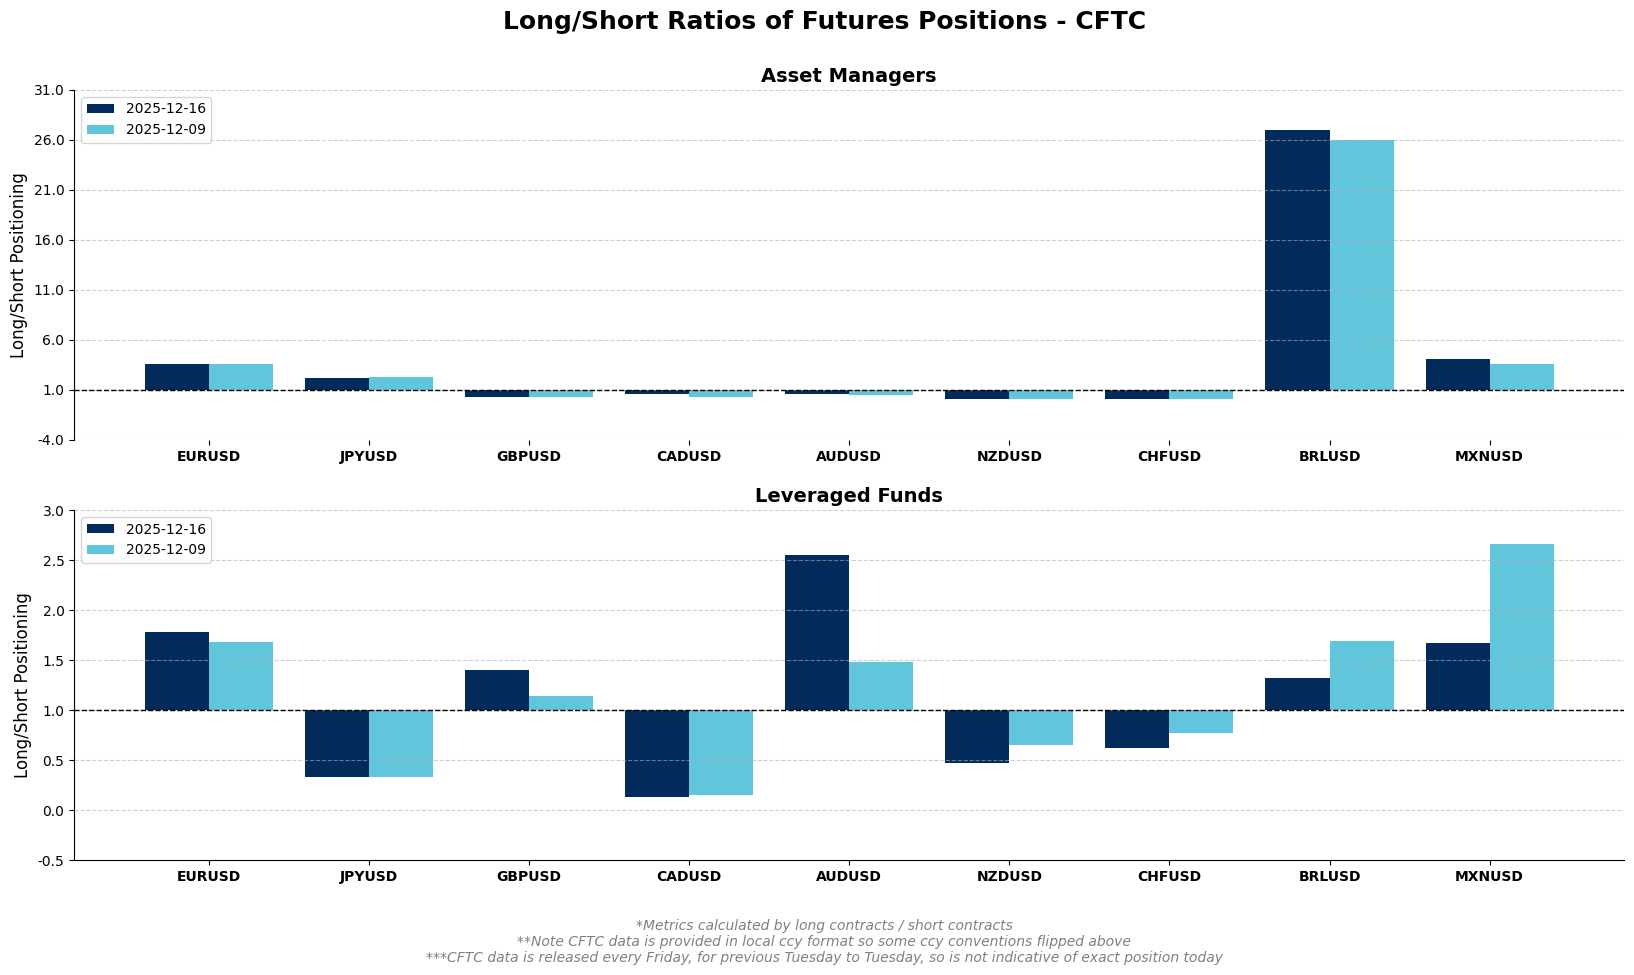

In [7]:
years = 2
plotTraderPositionalBarChart(years)

In [11]:
Traders_Agg_futurePositioning(years)

,EURUSD_AM_Long,EURUSD_AM_Short,EURUSD_Lever_Long,EURUSD_Lever_Short,JPYUSD_AM_Long,JPYUSD_AM_Short,JPYUSD_Lever_Long,JPYUSD_Lever_Short,GBPUSD_AM_Long,GBPUSD_AM_Short,...,CHFUSD_Lever_Long,CHFUSD_Lever_Short,BRLUSD_AM_Long,BRLUSD_AM_Short,BRLUSD_Lever_Long,BRLUSD_Lever_Short,MXNUSD_AM_Long,MXNUSD_AM_Short,MXNUSD_Lever_Long,MXNUSD_Lever_Short
2019-01-15,307519.0,161504.0,32090.0,111976.0,44815.0,16763.0,37230.0,69224.0,46502.0,89880.0,...,12231.0,15325.0,664.0,6084.0,9263.0,5765.0,97679.0,5673.0,73422.0,58533.0
2019-01-22,310543.0,162743.0,27903.0,112808.0,41915.0,16338.0,28994.0,49940.0,47669.0,80604.0,...,12569.0,13576.0,518.0,2652.0,7680.0,7433.0,107691.0,6698.0,81967.0,68542.0
2019-01-29,310178.0,159653.0,28376.0,112108.0,38614.0,15996.0,28909.0,42997.0,48092.0,69377.0,...,13358.0,14876.0,527.0,3480.0,8073.0,6988.0,113597.0,6544.0,83820.0,68790.0
2019-02-05,312234.0,157738.0,30090.0,107043.0,36295.0,20496.0,23184.0,25227.0,51168.0,67529.0,...,16425.0,16638.0,517.0,3467.0,9213.0,6741.0,129191.0,6743.0,80564.0,51753.0
2019-02-12,307217.0,169887.0,37918.0,122159.0,32976.0,26817.0,26572.0,25200.0,48744.0,77583.0,...,17302.0,19278.0,590.0,3000.0,8983.0,7648.0,138534.0,10174.0,72931.0,48932.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-10,330710.0,168176.0,76775.0,120696.0,50195.0,44923.0,30677.0,54242.0,52093.0,94431.0,...,3242.0,16087.0,21596.0,43010.0,12138.0,16190.0,38242.0,33805.0,56740.0,60936.0
2024-12-17,333070.0,170058.0,75931.0,114176.0,46402.0,52132.0,22969.0,60105.0,37375.0,95417.0,...,18487.0,15880.0,25475.0,46297.0,7790.0,14494.0,46284.0,36847.0,50090.0,48354.0
2024-12-24,339295.0,176429.0,69968.0,116500.0,51863.0,61797.0,31241.0,68682.0,35229.0,96873.0,...,11111.0,14081.0,25195.0,46895.0,9514.0,13937.0,49378.0,38192.0,54104.0,51753.0
2024-12-31,336955.0,183094.0,80796.0,122636.0,53727.0,62257.0,31671.0,73989.0,37075.0,92001.0,...,9895.0,15662.0,25183.0,50281.0,8461.0,15189.0,45967.0,39411.0,58102.0,55824.0


In [14]:
df = Traders_Agg_futurePositioning(years)

In [18]:
ccy_tickers = ['EURUSD', 'JPYUSD', 'GBPUSD', 'CADUSD', 'AUDUSD', 'NZDUSD', 'CHFUSD', 'BRLUSD', 'MXNUSD']

net_positions = {}
for ccy in ccy_tickers:

    net_positions[f'{ccy}_AM_Net'] = df[f'{ccy}_AM_Long'] - df[f'{ccy}_AM_Short']
    net_positions[f'{ccy}_Lever_Net'] = df[f'{ccy}_Lever_Long'] - df[f'{ccy}_Lever_Short']

df_netPos = pd.DataFrame(net_positions, index=df.index)

In [21]:
contract_sizes = {
    'GBPUSD': 62500,
    'JPYUSD': 12500000,
    'EURUSD': 125000,
    'AUDUSD': 100000,
    'CADUSD': 100000,
    'CHFUSD': 125000,
    'MXNUSD': 500000,
    'NZDUSD': 100000
}

In [22]:
for ccy, size in contract_sizes.items():
    df_netPos[f'{ccy}_AM_Net'] = df_netPos[f'{ccy}_AM_Net'] * size
    df_netPos[f'{ccy}_Lever_Net'] = df_netPos[f'{ccy}_Lever_Net'] * size

In [28]:
df_netPos.head()

,EURUSD_AM_Net,EURUSD_Lever_Net,JPYUSD_AM_Net,JPYUSD_Lever_Net,GBPUSD_AM_Net,GBPUSD_Lever_Net,CADUSD_AM_Net,CADUSD_Lever_Net,AUDUSD_AM_Net,AUDUSD_Lever_Net,NZDUSD_AM_Net,NZDUSD_Lever_Net,CHFUSD_AM_Net,CHFUSD_Lever_Net,BRLUSD_AM_Net,BRLUSD_Lever_Net,MXNUSD_AM_Net,MXNUSD_Lever_Net
2024-01-09,4.569400e+10,1.982625e+09,7.236250e+10,-5.641125e+11,-2.831875e+09,1.790500e+09,1.023600e+09,-3.558600e+09,-5.003800e+09,705400000.0,-5.248000e+08,323800000.0,-26375000.0,-100500000.0,36103.0,1482.0,7.321300e+10,1.783050e+10
2024-01-16,4.768925e+10,1.493125e+09,-9.325000e+10,-4.522875e+11,-2.247750e+09,1.742625e+09,-1.520000e+07,-3.206700e+09,-6.589100e+09,850100000.0,-5.194000e+08,89700000.0,-143875000.0,2625000.0,30606.0,4832.0,7.057650e+10,1.869650e+10
2024-01-23,4.722125e+10,4.460000e+08,-3.584250e+11,-3.562500e+11,-2.210625e+09,1.804000e+09,-1.298600e+09,-2.330300e+09,-7.225500e+09,525900000.0,-8.417000e+08,336900000.0,-327125000.0,53000000.0,29925.0,1265.0,6.912150e+10,1.367500e+10
2024-01-30,4.474962e+10,1.318625e+09,-4.338500e+11,-4.939250e+11,-2.107750e+09,1.719062e+09,-8.558000e+08,-2.087900e+09,-7.899800e+09,490200000.0,-1.059600e+09,391700000.0,-577750000.0,343875000.0,34309.0,-4530.0,7.158250e+10,1.286200e+10
2024-02-06,4.187100e+10,-6.665000e+08,-5.180750e+11,-5.048750e+11,-2.897938e+09,1.982000e+09,-3.886000e+08,-2.845200e+09,-9.032100e+09,978500000.0,-8.466000e+08,350600000.0,-577000000.0,-8375000.0,35519.0,-6890.0,7.450700e+10,1.432200e+10
